## Experiment 5 — Naive CUDA Matrix Multiplication



**Objective:**  
Implement a naive CUDA matrix-multiplication kernel and study how its performance changes as matrix size increases. Compare the custom kernel against PyTorch `torch.matmul` / cuBLAS to understand the performance gap between a straightforward GPU implementation and a highly optimized library implementation.

The experiment will focus on:

- Mapping CUDA threads to matrix output elements.
- Correctly indexing rows and columns of the input matrices.
- Computing one output element as the dot product of one row from matrix `A` and one column from matrix `B`.
- Benchmarking matrix sizes such as `N = 128, 256, 512, 1024, 2048`.
- Measuring kernel execution time and achieved throughput in **GFLOP/s**.
- Comparing the naive CUDA implementation with `torch.matmul`.
- Observing how global-memory access patterns, arithmetic intensity, parallelism, and lack of data reuse affect performance.
- Using the results to motivate why optimized matrix multiplication relies on techniques such as tiling, shared memory, register reuse, and specialized libraries like cuBLAS.



**Expected observation:**  
The naive CUDA kernel should produce correct results and benefit from GPU parallelism, but it is expected to perform significantly worse than `torch.matmul` / cuBLAS because it repeatedly accesses global memory and does not reuse matrix tiles efficiently.

## Implementation

In [1]:
!nvidia-smi

Wed Sep  9 05:30:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ninja

In [3]:
# import libraries
import torch # for pytorch
import pandas as pd # for data manipulation and plotting
from torch.utils.cpp_extension import load_inline # for loading cuda/c++ code
import matplotlib.pyplot as plt # for plotting
import time # for cpu timing

# versions
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")


PyTorch version: 2.11.0+cu128
CUDA available: True
cuDNN version: 91900


### Naive Matmul

In [9]:
cpp_code = """
#include <torch/extension.h>


//naive matrix multiplication prototype with signature
torch::Tensor naive_matmul(torch::Tensor A, torch::Tensor B, int block_x, int block_y);
"""

cuda_code = """

#include <torch/extension.h>
#include <cstdint>

// naive matrix multiplication kernel
__global__ void naive_matmul_kernel(const float* A, const float* B, float* C, int M, int N, int K) {

    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    
    if (row < M && col < K) {
        float sum = 0.0f;
        for (int i = 0; i < N; i++) {
            sum += A[row * N + i] * B[i * K + col];
        }
        C[row * K + col] = sum;
    }

}

// kernel launcher for naive matrix multiplication
torch::Tensor naive_matmul(torch::Tensor A, torch::Tensor B, int block_x, int block_y) {
    // Step 1: Implement Checks
    // 1.1: Check if the matrices are on the GPU
    TORCH_CHECK(A.device().is_cuda(), "A must be on the GPU");
    TORCH_CHECK(B.device().is_cuda(), "B must be on the GPU");
    // 1.2: Check if the matrices are float tensors
    TORCH_CHECK(A.dtype() == torch::kFloat32, "A must be a float tensor");
    TORCH_CHECK(B.dtype() == torch::kFloat32, "B must be a float tensor");
    // 1.3 Make sure the matrices are two dimensional only
    TORCH_CHECK(A.dim() == 2, "A must be a two dimensional tensor");
    TORCH_CHECK(B.dim() == 2, "B must be a two dimensional tensor");
    // 1.4 Check if the matrices are of the appropriate dimensions to allow matrix multiplication
    TORCH_CHECK(A.size(1) == B.size(0), "The number of columns in A must be equal to the number of rows in B");
    // 1.5 Make sure the matrices are contiguous
    TORCH_CHECK(A.is_contiguous(), "A must be contiguous");
    TORCH_CHECK(B.is_contiguous(), "B must be contiguous");
    // 1.6 Make sure the matrices are not empty
    TORCH_CHECK(A.size(0) > 0, "A must not be empty");
    TORCH_CHECK(B.size(0) > 0, "B must not be empty");

    // Step 2: Parameters to be Passed to the Kernel
    // 2.1: Get the dimensions of the matrices
    int M = A.size(0);
    int N = A.size(1);
    int K = B.size(1);
    // 2.2: Allocate memory for the result matrix
    torch::Tensor C = torch::zeros({M, K}, A.options());
    // 2.3: Get the device data pointers for the input and result matrices
    const float* A_ptr = A.data_ptr<float>();
    const float* B_ptr = B.data_ptr<float>();
    float* C_ptr = C.data_ptr<float>();
    // 2.4: Define the grid and block dimensions
    // Note: K is the number of columns in C , so we divide by the block size to get the number of blocks in the x direction
    // Note: M is the number of rows in C , so we divide by the block size to get the number of blocks in the y direction
    dim3 grid(
        (K+block_x-1)/block_x,
        (M+block_y-1)/block_y
    );
    dim3 block(block_x, block_y);
    // 2.5: Launch the kernel with the grid/block configuration (no shared memory so not third parameter)
    naive_matmul_kernel<<<grid, block>>>(A_ptr, B_ptr, C_ptr, M, N, K);
    // 2.6: Return the result matrix
    return C;
}

"""

In [10]:
try:
    module = load_inline(
        name="naive_matmul_v4",
        cpp_sources=cpp_code,
        cuda_sources=cuda_code,
        functions=["naive_matmul"],
        extra_cflags=["-O3"],
        extra_cuda_cflags=["-O3"],
        verbose=True,
    )
except Exception as e:
    print(e)

In [15]:
def benchmark(N, method="naive", warmup=10, runs=10):
    '''
    Benchmark the naive matrix multiplication kernel

    Args:
        N (int): The size of the matrix
    '''
    # Set the block size
    block_x = 16
    block_y = 16
    
    # Create random matrices
    A = torch.randn(N, N, device="cuda")
    B = torch.randn(N, N, device="cuda")

    # warmup

    for _ in range(warmup):
        if method == "naive":
            module.naive_matmul(A, B, block_x, block_y)
        else:
            torch.matmul(A, B)

    start_cuda = torch.cuda.Event(enable_timing=True)
    end_cuda = torch.cuda.Event(enable_timing=True)
    
    if method == "naive":
        start_cuda.record()
        for _ in range(runs):
            C = module.naive_matmul(A, B, block_x, block_y)
        end_cuda.record()
        torch.cuda.synchronize()
        print("Used Naive Matmul")
    elif method == "torch":
        start_cuda.record()
        for _ in range(runs):
            C = torch.matmul(A, B)
        end_cuda.record()
        torch.cuda.synchronize()
        print("UsedTorch Matmul")
    elapsed_time = start_cuda.elapsed_time(end_cuda)/runs
    # Calculate the GFLOP/s
    gflops = 2 * N * N * N / (elapsed_time * 1e6)
    return gflops





    

Used Naive Matmul
UsedTorch Matmul
Used Naive Matmul
UsedTorch Matmul
Used Naive Matmul
UsedTorch Matmul
Used Naive Matmul
UsedTorch Matmul
Used Naive Matmul
UsedTorch Matmul


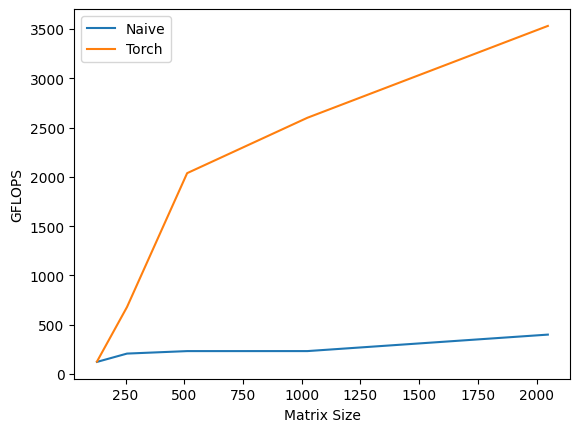

In [16]:
N_array = [128, 256, 512, 1024, 2048]
gflops_naive_array = []
gflops_torch_array = []
for N in N_array:
    gflops_naive = benchmark(N, method="naive")
    gflops_torch = benchmark(N, method="torch")
    gflops_naive_array.append(gflops_naive)
    gflops_torch_array.append(gflops_torch)

plt.plot(N_array, gflops_naive_array, label="Naive")
plt.plot(N_array, gflops_torch_array, label="Torch")
plt.xlabel("Matrix Size")
plt.ylabel("GFLOPS")
plt.legend()
plt.show()


## Observations


- The naive CUDA matrix-multiplication kernel achieves significantly lower throughput than `torch.matmul`.
- As matrix size increases, both implementations improve because larger workloads better utilize the GPU.
- The naive kernel scales much more slowly and reaches only a few hundred GFLOP/s, while `torch.matmul` reaches several thousand GFLOP/s.
- The performance gap comes from the naive implementation repeatedly loading matrix elements from global memory without tiling or reuse.
- `torch.matmul`/cuBLAS uses highly optimized techniques such as blocking, shared-memory/register reuse, better memory-access patterns, and specialized matrix-multiplication instructions.
- This experiment shows that parallelizing matrix multiplication is not enough by itself; efficient data reuse and memory hierarchy usage are essential for high-performance GEMM.